# Generate Fitness Landscape Constraints for gRNAde Design

This notebook generates position-specific design constraints for the 5TU catalytic subunit, which guide the gRNAde pipeline to preferentially redesign tolerable positions while preserving functionally critical residues.

**Saved constraint arrays** (used by design notebooks):
- `fitness_landscape_constraints/max_fitness_array.npy`: Best single-mutant fitness per position
- `fitness_landscape_constraints/combinability_array.npy`: Epistatic combinability scores

## Input Data Sources

**Fitness landscape** (McRae et al. 2024):
- Comprehensive mutational scanning of 5TU variants (1-4 mutations)
- Deep mutational scanning data from PNAS paper: "Cryo-EM structure and functional landscape of an RNA polymerase ribozyme"
- Source file: `fitness_landscape_constraints/5TU_fitness_landscape.csv`

**3D structure** (PDB: 8T2P):
- Cryo-EM structure of TPR heterodimer (5TU + t1 auxiliary subunit)
- Used to compute structural features: dimer interface, base-pairing patterns
- Identifies critical tertiary contacts (kissing-loop interactions)


In [1]:
import re
import itertools
from copy import deepcopy
from math import comb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Sequence, Union
from dataclasses import dataclass

from __future__ import annotations

# Mutational Data Helpers

Utility classes for parsing and manipulating RNA sequence variants:
- **`Mutation`**: Single substitution (e.g., "G15A" means position 15: G→A)
- **`Variant`**: Collection of mutations defining a sequence variant
- **`parse_variant()`**: Extract mutations by comparing sequences
- **`compute_mutation_coverage_at_order()`**: Check if mutation combinations exist in dataset

**Credit**: Simon Mathis

In [2]:
NA_PATTERN = "[ACTG\*\-]"
SEP_PATTERN = "[\s,;]+"
MUTATION_PATTERN = re.compile(NA_PATTERN + r"\d+" + NA_PATTERN)

@dataclass
class Mutation:
    """
    Mutation counting is 0-indexed internally to reduce errors,
    but the printout is 1-indexed for consistency with the standard mutation
    numbering scheme.
    """

    pos: int
    to_seq: str
    from_seq: str = None
    type: str = "substitution"

    @property
    def name(self) -> str:
        if self.type == "substitution":
            # +1 to make it 1-indexed
            return f"{self.from_seq}{self.pos + 1}{self.to_seq}"

    def validate(self) -> None:
        if self.type == "substitution":
            assert len(self.from_seq) == 1, "Substitution mutation from_seq must be length 1"
            assert len(self.to_seq) == 1, "Substitution mutation to_seq must be length 1"
            assert self.from_seq != self.to_seq, "Mutation from_seq and to_seq are the same"
            assert self.pos >= 0, "Mutation position must be >= 0"
        else:
            raise NotImplementedError

    @staticmethod
    def from_str(mutation_str: str) -> "Mutation":
        mutation_str = mutation_str.strip()
        assert re.match(MUTATION_PATTERN, mutation_str), "Invalid mutation string %s" % mutation_str
        pos = (
            int(re.search(r"\d+", mutation_str).group()) - 1
        )  # -1 bc. string notation is 1-indexed
        from_seq = re.search(r"^" + NA_PATTERN, mutation_str).group()
        to_seq = re.search(NA_PATTERN + r"$", mutation_str).group()
        mut = Mutation(pos=pos, from_seq=from_seq, to_seq=to_seq)
        mut.validate()
        return mut

    def invert(self) -> Mutation:
        if not self.type == "substitution":
            raise NotImplementedError
        return Mutation(pos=self.pos, from_seq=self.to_seq, to_seq=self.from_seq)

    def __eq__(self, other: Mutation) -> bool:
        if isinstance(other, Mutation):
            return str(self) == str(other)
        elif isinstance(other, str):
            return str(self) == other
        elif isinstance(other, Variant):
            return len(other) == 1 and other.mutations[0] == self
        else:
            raise NotImplementedError(
                "Can only compare Mutation to Mutation, Variant or str, not %s" % type(other)
            )

    def __hash__(self) -> int:
        return hash(str(self))

    def __str__(self) -> str:
        return self.name


class Variant:
    def __init__(self, mutations: Sequence[Mutation]) -> None:
        self.mutations = sorted(mutations, key=lambda x: x.pos)

    @property
    def is_wildtype(self) -> bool:
        return len(self.mutations) == 0

    def __len__(self) -> int:
        return len(self.mutations)

    def get_sequence(self, wildtype: str, validate: bool = True) -> str:
        seq = deepcopy(wildtype)
        for mutation in self.mutations:
            if validate:
                mutation.validate()
                if wildtype[mutation.pos] != mutation.from_seq:
                    raise ValueError(
                        f"Position {mutation.pos} is {wildtype[mutation.pos]} and not {mutation.from_seq} in wildtype sequence"
                    )
            if mutation.type == "substitution":
                seq = seq[: mutation.pos] + mutation.to_seq + seq[mutation.pos + 1 :]
            else:
                raise NotImplementedError
                # TODO: Implement insertion, deletion and grouping of canonical
                #  grouping of mutations (ie. how to deal with multiple mutations)
                #  that change sequence length
        return seq

    def __str__(self) -> str:
        return ",".join(f"{m.name}" for m in self.mutations)

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}({self})"
    
    def __contains__(self, variant: Mutation | Variant | str) -> bool:
        if isinstance(variant, Mutation):
            return variant in self.mutations
        elif isinstance(variant, str):
            variant = Variant.from_str(variant)
            return self.__contains__(variant)
        elif isinstance(variant, Variant):
            return all(m in self.mutations for m in variant.mutations)
        else:
            raise NotImplementedError(
                "Can only compare Mutation to Mutation, Variant or str, not %s" % type(variant)
            )

    @staticmethod
    def from_mutated_seq(sequence: str, wildtype: str) -> "Variant":
        return parse_variant(sequence, wildtype)

    @staticmethod
    def from_str(variant_str: str) -> "Variant":
        if variant_str == "":
            return Variant([])
        mutations = re.split(f"\s*{SEP_PATTERN}\s*", variant_str.strip())
        mutations = [Mutation.from_str(m) for m in mutations]
        return Variant(mutations)

    def invert(self) -> Variant:
        return Variant([m.invert() for m in self.mutations])

    def __eq__(self, other: Variant) -> bool:
        if isinstance(other, Variant):
            return str(self) == str(other)
        elif isinstance(other, str):
            return str(self) == other
        elif isinstance(other, Mutation):
            return len(self) == 1 and self.mutations[0] == other
        else:
            raise NotImplementedError(
                "Can only compare Variant to Variant, Mutation or str, not %s" % type(other)
            )

    def __hash__(self) -> int:
        return hash(str(self))

    def __lt__(self, other: Variant) -> bool:
        return str(self) < str(other)

    def __gt__(self, other: Variant) -> bool:
        return str(self) > str(other)

    def __le__(self, other: Variant) -> bool:
        return str(self) <= str(other)

    def __ge__(self, other: Variant) -> bool:
        return str(self) >= str(other)


def parse_variant(sequence: str, wildtype: str) -> Variant:
    assert len(sequence) == len(
        wildtype
    ), "Sequence and wildtype must be the same length. INDELS not yet supported."
    mutations = []
    for pos in range(len(sequence)):
        if sequence[pos] != wildtype[pos]:
            mutations.append(Mutation(pos, sequence[pos], wildtype[pos]))
    return Variant(mutations)


def compute_mutation_coverage_at_order(
    variant: str | Variant, covered: set[str], order: int, normalise: bool = True
):
    if isinstance(variant, str):
        variant = Variant.from_str(variant)

    if order >= len(variant):
        return np.nan

    # For subset of mutations of length `order` in `variant`, check if they are
    # the combination of mutations in `covered`. If so, add +1 to coverage.
    coverage = 0
    for ms in itertools.combinations(variant.mutations, order):
        v = Variant(ms)
        if str(v) in covered:
            coverage += 1

    # Normalise the coverage value to from an absolute count to a fraction
    # in [0, 1]s
    if normalise:
        coverage /= comb(len(variant), order)

    return coverage


def count_possible_mutations(seq_len: int, n_mut: int, alphabet_size: int = 20) -> int:
    """
    Count the number of possible mutations of length `n_mut` in a sequence of length `seq_len`.
    """
    return comb(seq_len, n_mut) * (alphabet_size - 1) ** n_mut

# Define Wild-Type 5TU Sequence

The 152-nucleotide reference sequence for the catalytic 5TU subunit from the triplet-based RNA polymerase ribozyme (TPR). All mutations in the fitness landscape are defined relative to this wild-type sequence.

In [3]:
wt_seq = 'GGAUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUGAGAGCAUCUUCGGAUGCAGAGGCGGCAGCCUUCGGUGGCGCGAUAGCGCCAACGUUCUCAACUAUGACACGCAAAACGCGUGCUCCGUUGAAUGGAGUUUAUCAUG'
wt_seq = wt_seq.replace('U', 'T')

# Load Fitness Landscape Data

Import comprehensive mutational scanning data from **McRae et al. (PNAS, 2024)**: "Cryo-EM structure and functional landscape of an RNA polymerase ribozyme".

In [4]:
df_mut = pd.read_csv("fitness_landscape_constraints/5TU_fitness_landscape.csv", header=None, names=["variant", "fitness"])
df_mut.variant = df_mut.variant.str.replace("WT", "")
df_mut = df_mut.query("~variant.str.contains('del|ins', regex=True)").copy()
df_mut["variant_obj"] = df_mut.variant.apply(Variant.from_str)
df_mut["seq"] = df_mut.variant_obj.apply(lambda x: x.get_sequence(wt_seq))
df_mut["n_mut"] = df_mut.variant_obj.apply(len)
df_mut

,variant,fitness,variant_obj,seq,n_mut
0,,0.000000,,GGATCTTCTCGATCTAACAAAAAAGACAAATCTGCCACAAAGCTTG...,0
1,C85A,-1.279749,C85A,GGATCTTCTCGATCTAACAAAAAAGACAAATCTGCCACAAAGCTTG...,1
2,C87T,-0.595705,C87T,GGATCTTCTCGATCTAACAAAAAAGACAAATCTGCCACAAAGCTTG...,1
3,C85T,-0.512518,C85T,GGATCTTCTCGATCTAACAAAAAAGACAAATCTGCCACAAAGCTTG...,1
4,C85G,-2.050369,C85G,GGATCTTCTCGATCTAACAAAAAAGACAAATCTGCCACAAAGCTTG...,1
...,...,...,...,...,...
84819,C5T C54T T82A C95G A147T,-1.274958,"C5T,C54T,T82A,C95G,A147T",GGATTTTCTCGATCTAACAAAAAAGACAAATCTGCCACAAAGCTTG...,5
84821,A20T C76A C93A T101C T104G G141C C149G G152C,-4.687890,"A20T,C76A,C93A,T101C,T104G,G141C,C149G,G152C",GGATCTTCTCGATCTAACATAAAAGACAAATCTGCCACAAAGCTTG...,8
84822,A47G A60T G86T G100A C108A C125G,-4.718979,"A47G,A60T,G86T,G100A,C108A,C125G",GGATCTTCTCGATCTAACAAAAAAGACAAATCTGCCACAAAGCTTG...,6
84823,T4G T15G A20G A39C C85G A107G,-4.441395,"T4G,T15G,A20G,A39C,C85G,A107G",GGAGCTTCTCGATCGAACAGAAAAGACAAATCTGCCACCAAGCTTG...,6


Mutation order 1:             449 /             456 ( 98.4649%)
Mutation order 2:          10,493 /         103,284 ( 10.1594%)
Mutation order 3:          11,411 /      15,492,600 (  0.0737%)
Mutation order 4:          13,651 /   1,731,298,050 (  0.0008%)
Mutation order 5:          13,438 / 153,739,266,840 (  0.0000%)
Mutation order 6:          10,829 / 11,299,836,112,740 (  0.0000%)
Mutation order 7:           7,181 / 707,046,888,197,160 (  0.0000%)
Mutation order 8:           4,104 / 38,445,674,545,720,575 (  0.0000%)
Mutation order 9:           1,999 / 1,845,392,378,194,587,600 (  0.0000%)
Mutation order 10:             913 / 79,167,333,024,547,808,040 (  0.0000%)
Mutation order 11:             320 / 3,065,934,897,132,487,838,640 (  0.0000%)
Mutation order 12:             114 / 108,074,205,123,920,196,312,060 (  0.0000%)
Mutation order 13:              27 / 3,491,628,165,542,037,111,620,400 (  0.0000%)
Mutation order 14:              11 / 104,000,638,930,787,819,681,836,200 (  0.000

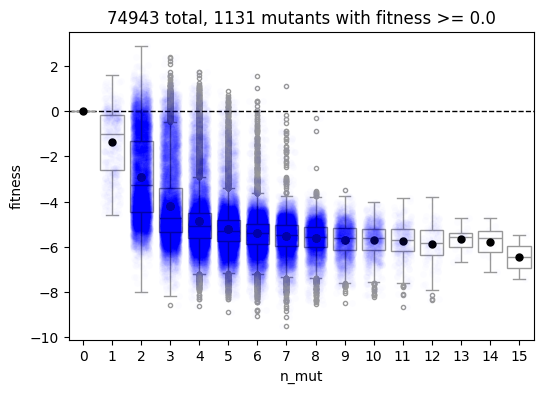

In [5]:
for i in range(1, 50):
    in_dataset = len(df_mut.query(f"n_mut=={i}"))
    if in_dataset == 0: break
    in_possible = count_possible_mutations(len(wt_seq), i, 4)
    print(f"Mutation order {i}: {in_dataset:>15,} / {in_possible:>15,} ({100*in_dataset/in_possible:>8.4f}%)".ljust(60))
print(f"Total dataseta size: {len(df_mut):>15,}")

plt.figure(figsize=(6, 4))
sns.stripplot(
    data=df_mut,
    x="n_mut",
    y="fitness",
    jitter=0.3,
    alpha=0.01,
    color="blue",
)
sns.boxplot(
    data=df_mut,
    x="n_mut",
    y="fitness",
    color="white",
    linewidth=1,
    fliersize=3,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":5},
)
plt.axhline(0, color='black', lw=1, ls='--')
plt.title(f"{len(df_mut)} total, {len(df_mut[df_mut.fitness >= 0.0])} mutants with fitness >= 0.0")
plt.show()

# Structural Analysis from Cryo-EM Structure

Analyze the 3D structure of the TPR heterodimer (PDB: 8T2P) to identify structural features that constrain design:

1. **Solvent Accessible Surface Area (SASA)**: Identifies buried vs exposed residues
2. **Dimer interface distances**: Measures proximity to t1 auxiliary subunit
3. **Base-pairing patterns**: Detects Watson-Crick pairs, wobble pairs (G-U), and unpaired regions
4. **Kissing-loop interactions**: Critical tertiary contacts between chain A (t1) and chain B (5TU)

Mainly used to identify the dimer interface and kissing loops.

**Credit**: Simon Mathis

In [6]:
import biotite.database.rcsb as rcsb
import biotite.structure.io.pdb as pdb
import biotite.structure.io as bsio 
import biotite.structure as bs

structure = pdb.PDBFile.read(rcsb.fetch("8T2P", "pdb")).get_structure(model=1)
structure = structure[structure.res_name != "HOH"]
rna = structure[bs.filter_polymer(structure, pol_type="nucleotide")]
ligands = structure[~bs.filter_polymer(structure, pol_type="nucleotide")]
print(f"RNA: {bs.get_chain_count(rna)} chains, {bs.get_residue_count(rna)} residues, {len(rna)} atoms")
print(f"Ligands: {bs.get_chain_count(ligands)} chains, {bs.get_residue_count(ligands)} residues, {len(ligands)} atoms")
rna_t1 = rna[rna.chain_id == "A"]
rna_5tu = rna[rna.chain_id == "B"]

RNA: 2 chains, 287 residues, 9206 atoms
Ligands: 1 chains, 1 residues, 0 atoms


In [7]:
def get_min_distance_to_reference_points(structure, ref_points):
    """
    Get the minimum distance between each atom in the structure and a set of reference points.
    """
    # Calculate the pairwise distances between the side chain atoms of the catalytic residues
    # and all other side chain atoms in the rna structure using NumPy broadcasting
    diffs = structure.coord[:, np.newaxis] - ref_points
    pairwise_distances = np.sqrt(np.sum(diffs**2, axis=-1))

    # Find the minimum distance for each rna atom to any catalytic atom
    min_distances = np.min(pairwise_distances, axis=-1)

    return min_distances

def get_interface_distances(structure: bs.AtomArray) -> Dict[str, np.ndarray]:
    chains = np.unique(structure.chain_id)

    chain_interfaces = itertools.combinations(chains, 2)

    interface_distance = {}
    for chain1, chain2 in chain_interfaces:
        chain1_atoms = structure[structure.chain_id == chain1]
        chain2_atoms = structure[structure.chain_id == chain2]

        interface_distance[f"{chain1}>{chain2}"] = get_min_distance_to_reference_points(
            chain1_atoms, chain2_atoms.coord
        )
        interface_distance[f"{chain2}>{chain1}"] = get_min_distance_to_reference_points(
            chain2_atoms, chain1_atoms.coord
        )

    return interface_distance

def calc_residue_rsasa(structure: bs.AtomArray, **kwargs) -> np.ndarray:
    # Calculate the SASA for each residue
    sasas = calc_residue_sasa(protein, **kwargs)

    # Calculate the maximum possible SASA for each residue
    max_sasas = [MAX_RES_SASA["Tien_2013_theoretical"][res] for res in bs.get_residues(protein)[1]]

    # Calculate the relative SASA for each residue
    rsasas = sasas / max_sasas

    return rsasas

def residue_sasa(structure: bs.AtomArray, **kwargs) -> np.ndarray:
    # Calculate atom level SASA
    sasa_per_atom = bs.sasa(structure, **kwargs)

    # Pool SASAs for each residue
    sasa_per_residue = bs.apply_residue_wise(structure, sasa_per_atom, np.nansum)
    return sasa_per_residue

def find_hydrogen_bonded_pairs(rna, dist_cutoff=3.8):  # 3.8
    """
    Identifies specific hydrogen-bonded nucleotides in an RNA structure, considering the correct number of hydrogen bonds
    for A-U (2 bonds), G-C (3 bonds), and G-U wobble pairs (2 bonds).
    
    Parameters:
    rna : AtomArray
        The RNA structure.
    
    Returns:
    list of tuples
        Each tuple contains (chain_id, res_id, res_name) of the nucleotide and its bonded partner, if the correct number of hydrogen bonds is met.
    """
    bond_criteria = {
        ('A', 'U'): [('N6', 'O4'), ('N1', 'N3')],  # A-U forms 2 hydrogen bonds
        ('U', 'A'): [('O4', 'N6'), ('N3', 'N1')],
        ('G', 'C'): [('N1', 'N3'), ('O6', 'N4'), ('N2', 'O2')],  # G-C forms 3 hydrogen bonds
        ('C', 'G'): [('N3', 'N1'), ('N4', 'O6'), ('O2', 'N2')],
        ('G', 'U'): [('N1', 'O4'), ('N2', 'O2')],  # G-U wobble pair forms 2 hydrogen bonds
        ('U', 'G'): [('O4', 'N1'), ('O2', 'N2')],
    }
    
    paired_nucleotides = []
    
    # Iterate over each residue to find its potential bonding partner
    for residue in bs.residue_iter(rna):
        res_id = residue.res_id[0]
        res_name = residue.res_name[0]
        chain_id = residue.chain_id[0]
        
        for (base1, base2), atom_pairs in bond_criteria.items():
            if res_name == base1:
                potential_partners = rna[rna.res_name == base2]
                bonds = 0
                for atom1, atom2 in atom_pairs:
                    if len(potential_partners) == 0:
                        continue
                    target_atom = residue[residue.atom_name == atom1]
                    assert len(target_atom) == 1
                    partner_atoms = potential_partners[potential_partners.atom_name == atom2]
                    distance = bs.distance(target_atom, partner_atoms)
                    potential_partners = potential_partners[bs.spread_residue_wise(potential_partners, distance) < dist_cutoff]
                    bonds += 1
                if (len(potential_partners) > 0) and len(atom_pairs) == bonds:  # Check if the number of confirmed bonds matches expected
                    #if len(bs.get_residues(potential_partners)[0]) > 1:
                    #    logger.warning(f"Target residue {chain_id}:{res_id} had {len(bs.get_residues(potential_partners)[0])} partners: \n\nPartners:{potential_partners}")
                    partner_res_id = partner_atoms.res_id[0]  # Simplification, assumes last checked atom's residue
                    partner_chain_id = partner_atoms.chain_id[0]
                    partner_res_name = partner_atoms.res_name[0]
                    paired_nucleotides.append(((chain_id, res_id, res_name), (partner_chain_id, partner_res_id, partner_res_name)))
    
    return paired_nucleotides

max_rna_nt_sasa = {
    NT: np.percentile(list(map(residue_sasa, bs.residue_iter(rna[rna.res_name == NT]))), q=95)
    for NT in ["A", "C", "G", "U"]
}

distance_to_interface = get_interface_distances(rna)
sasa = residue_sasa(rna)
rsasas = sasa / np.array([max_rna_nt_sasa[res.res_name[0]] for res in bs.residue_iter(rna)])
res_pairs = {partner1: partner2 for (partner1, partner2) in find_hydrogen_bonded_pairs(rna)}
res_is_paired = np.array([
    res_pairs.get((res.chain_id[0], res.res_id[0], res.res_name[0]), None) is not None
    for res in bs.residue_iter(rna)
])

paired_res_chain = np.array([
    res_pairs.get((res.chain_id[0], res.res_id[0], res.res_name[0]), ("", np.nan, ""))[0].strip()
    for res in bs.residue_iter(rna)
])

paired_res_id = np.array([
    res_pairs.get((res.chain_id[0], res.res_id[0], res.res_name[0]), ("", np.nan, ""))[1]
    for res in bs.residue_iter(rna)
])

paired_res_name = np.array([
    res_pairs.get((res.chain_id[0], res.res_id[0], res.res_name[0]), ("", np.nan, ""))[2]
    for res in bs.residue_iter(rna)
])

rna.set_annotation("atom_dimer_dist", np.concatenate([distance_to_interface["A>B"], distance_to_interface["B>A"]]))
rna.set_annotation("res_sasa", bs.spread_residue_wise(rna, bs.spread_residue_wise(rna, sasa)))
rna.set_annotation("res_dimer_dist", bs.spread_residue_wise(rna, bs.apply_residue_wise(rna, rna.atom_dimer_dist, lambda x, **kwargs: x.min(**kwargs))))
rna.set_annotation("rsasas", bs.spread_residue_wise(rna, rsasas))
rna.set_annotation("res_is_paired", bs.spread_residue_wise(rna, res_is_paired))
rna.set_annotation("paired_res_chain", bs.spread_residue_wise(rna, paired_res_chain))
rna.set_annotation("paired_res_id", bs.spread_residue_wise(rna, paired_res_id))
rna.set_annotation("paired_res_name", bs.spread_residue_wise(rna, paired_res_name))

# Turn int odataframe:
structure_feat_df = pd.DataFrame({
    "chain_id": rna.chain_id,
    "res_id": rna.res_id,
    "res_name": rna.res_name,
    "atom_name": rna.atom_name,
    "res_sasa": rna.res_sasa,
    "res_dimer_dist": rna.res_dimer_dist,
    "res_rsasa": rna.rsasas,    
    "atom_dimer_dist": rna.atom_dimer_dist,
    "res_is_paired": rna.res_is_paired,
    "paired_res_chain": rna.paired_res_chain,
    "paired_res_id": rna.paired_res_id,
    "paired_res_name": rna.paired_res_name,
})

structure_feat_df["wobble_pair"] = structure_feat_df.apply(lambda x: x.res_is_paired & ((x.res_name == "G" and x.paired_res_name == "U") or (x.res_name == "U" and x.paired_res_name == "G")), axis=1)
structure_feat_df["within_chain_pair"] = structure_feat_df.apply(lambda x: x.res_is_paired & (x.chain_id == x.paired_res_chain), axis=1)
structure_feat_df["across_chain_pair"] = structure_feat_df.apply(lambda x: x.res_is_paired & (x.chain_id != x.paired_res_chain), axis=1)
df = structure_feat_df.query("chain_id=='B'").copy()

In [8]:
print(df.groupby("res_id").head(1).wobble_pair.value_counts())
print(df.groupby("res_id").head(1).within_chain_pair.value_counts())
print(df.groupby("res_id").head(1).across_chain_pair.value_counts())

wobble_pair
False    148
True       4
Name: count, dtype: int64
within_chain_pair
True     90
False    62
Name: count, dtype: int64
across_chain_pair
False    144
True       8
Name: count, dtype: int64


# Compute Position-Specific Fitness Arrays

Extract single-mutant fitness statistics for each of the 152 positions:

## Fitness Metrics Per Position

- **Maximum fitness**: Best single mutation at each position (used as primary constraint)
- **Median fitness**: Central tendency of mutational effects
- **Q25/Q75 fitness**: Interquartile range measuring variability

## Structural Region Identification

Define functionally critical regions based on structural features:
- **Surface residues**: High SASA (>40% relative exposure)
- **Paired residues**: Involved in base-pairing
- **Wobble pairs**: G-U non-canonical pairs
- **Dimer interface**: Within 5.0 Å of t1 subunit
- **Across-chain pairs**: Tertiary kissing-loop contacts

In [9]:
df_singles = df_mut.query("n_mut==1").copy()
df_singles["pos"] = df_singles.variant_obj.apply(lambda x: x.mutations[0].pos)
median_fitness = df_singles.groupby("pos").fitness.median()
q25_fitness = df_singles.groupby("pos").fitness.quantile(0.25)
q75_fitness = df_singles.groupby("pos").fitness.quantile(0.75)
max_fitness = df_singles.groupby("pos").fitness.max()
median_fitness_array = np.zeros(len(wt_seq))
q25_fitness_array = np.zeros(len(wt_seq))
q75_fitness_array = np.zeros(len(wt_seq))
max_fitness_array = np.zeros(len(wt_seq))
for i in range(len(wt_seq)):
    median_fitness_array[i] = median_fitness.get(i, 0)
    q25_fitness_array[i] = q25_fitness.get(i, 0)
    q75_fitness_array[i] = q75_fitness.get(i, 0)
    max_fitness_array[i] = max_fitness.get(i, 0)

surface_res = df.groupby("res_id").head(1).query("res_rsasa > 0.4").res_id.values
paired_res = df.groupby("res_id").head(1).query("res_is_paired").res_id.values
wobble_pairs = df.groupby("res_id").head(1).query("wobble_pair").res_id.values
across_chain_pairs = df.groupby("res_id").head(1).query("across_chain_pair").res_id.values

DIMER_INTERFACE_THRESHOLD = 5.0

dimer_interface = df.groupby("res_id").min().query(f"res_dimer_dist < {DIMER_INTERFACE_THRESHOLD}").index.values

# Calculate Epistatic Combinability Scores

Compute **combinability** metric following **Gantz et al. (2024)**: "Microdroplet screening rapidly profiles a biocatalyst to enable its AI-assisted engineering" (bioRxiv).

For each position, combinability measures how well mutations at that position work in combination with other mutations:

1. For each functional multi/-mutant variant (fitness > 0):
   - Compare observed fitness to additive expectation (sum of single-mutant effects)
   - If observed > additive (positive epistasis), increment combinability for each position
   - Combinability score weighted by variant order (length)

2. Positions with high combinability:
   - Mutations combine favorably with other changes
   - Suitable for multi-mutational jumps in sequence space

In [10]:
def compute_combinability(wt, df_mut):
    combinability = np.zeros(len(wt))

    singles = df_mut.query("n_mut==1").copy()
    higher_order = df_mut.query("n_mut>1").copy()
    for i, row in higher_order.iterrows():
        variant = row.variant_obj
        if row.fitness <= 0.0:
            continue
        # Compute additive fitness:
        _singles_in_variant = list(map(str,variant.mutations))
        additive_fitness = singles.query(f"variant_obj in @_singles_in_variant").fitness.sum()
        if row.fitness < additive_fitness:
            continue
        else: 
            for mut in variant.mutations:
                combinability[mut.pos] += len(variant)  # 0-indexed
    return combinability

combinability_array = compute_combinability(wt_seq, df_mut.query("n_mut<5").copy())

/tmp/ipykernel_68020/614508953.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap)


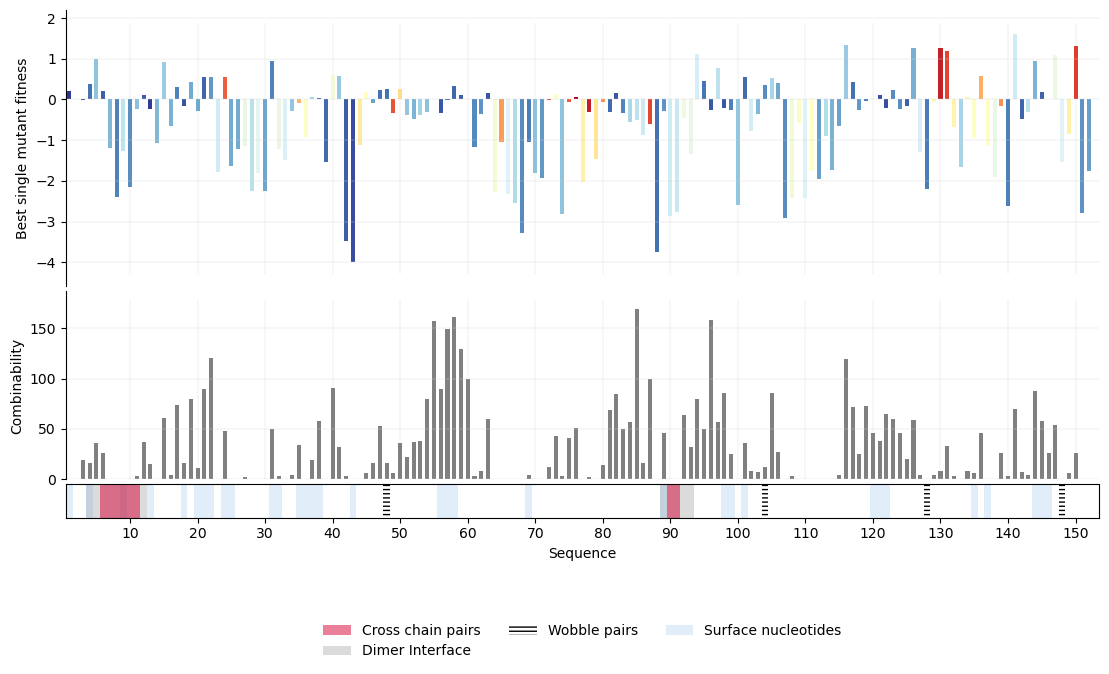

In [12]:
import matplotlib as mpl
from matplotlib import patches
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotstyle
from plotstyle.export import save_timestamped_figure
from plotstyle.colors import cambridge_light, cambridge_core, cambridge_dark
from plotstyle.typesetting import latex_is_available
from plotstyle.size import convert_unit, get_dim, set_dim, WIDTH, GOLDEN_RATIO

sequence_length = len(wt_seq)
use_one_indexing = True
mpl.rcParams['hatch.linewidth'] = 1  # or any other float value for thickness

# Create a figure and axis
fig, axes = plt.subplots(figsize=get_dim(WIDTH.powerpoint_widescreen, ratio=GOLDEN_RATIO * 0.8), nrows=3, height_ratios=[0.5, 0.34, 0.06], sharex=False)

# Round the xticks to the nearest 10 and fit `_n_ticks` ticks
_n_ticks = 20
_step_size = round(int(np.ceil(sequence_length / _n_ticks)) / 10) * 10
xticks = np.arange(
    0, sequence_length + 1, _step_size
)  # +1 because mutation notation is 1 indexed

values = combinability_array
hue = None
color="gray"
cmap = "RdYlBu_r"

ax = axes[1]

# Bar plot along the sequence values
offset = 1 if use_one_indexing else 0
pos = np.arange(offset, sequence_length + offset)
ax.bar(pos, values, align="center", width=0.6, color=color)

ax.set_ylabel("Combinability")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
# Set yticks
#ax.set_yticks([0, 250, 500])
ax.set_xlim(offset - 0.5, sequence_length + offset + 0.5)

# PLOT 2 -- Median fitness
ax = axes[0]
values = max_fitness_array
hue = q75_fitness_array - q25_fitness_array

# Set color map
if hue is not None:
    assert len(hue) == sequence_length, "Hue must be the same length as the sequence"
    if hue.min() < 0 and hue.max() > 0:
        # set the color map to be diverging
        cnorm = mpl.colors.TwoSlopeNorm(vmin=hue.min(), vcenter=0.0, vmax=hue.max())
    else:
        # set the color map to be sequential
        cnorm = mpl.colors.Normalize(vmin=hue.min(), vmax=hue.max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=cnorm)
    sm.set_array([])
    cmap = plt.cm.get_cmap(cmap)
    color = cmap(cnorm(hue))

# Bar plot along the sequence values
offset = 1 if use_one_indexing else 0
pos = np.arange(offset, sequence_length + offset)
ax.bar(pos, values, align="center", width=0.6, color=color)

ax.set_ylabel("Best single mutant fitness")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_xlim(offset - 0.5, sequence_length + offset + 0.5)
# Set xticks and use for grid but hide labels and tick marks

# PLOT 3 -- Orientation bar
ax = axes[2]
# Function to add shaded or hatched areas
def add_annotation(indices, color=None, hatch=None, alpha=0.99, width=1, height=1):
    for index in indices:
        if color is None:
            # Set transparent facecolor
            facecolor = (1, 1, 1, 0)  # Fully transparent white
        else:
            # Apply alpha only to facecolor, not to the hatch
            facecolor = (*mpl.colors.to_rgb(color), alpha)
        
        ax.add_patch(patches.Rectangle((index - 0.5, 0), width, height, facecolor=facecolor, hatch=hatch, edgecolor=None))

# Add your annotations
add_annotation(dimer_interface, color='lightgray', alpha=0.8)
add_annotation(surface_res, color=cambridge_light[1], alpha=0.2)
add_annotation(across_chain_pairs, color=cambridge_core[0], alpha=0.5)
add_annotation(wobble_pairs, hatch=r'-'*4, alpha=0.99)

# Set limits and labels
ax.set_xlim(0, 289)
ax.set_ylim(0, 1)
ax.set_xlabel('Sequence')
ax.set_yticks([])  # Hide y-axis ticks
ax.set_xticks(xticks)
ax.set_xlim(offset - 0.5, sequence_length + offset + 0.5)

# Make grid lines thinner and in the background
for ax in axes[:-1]:
    ax.set_xticks([])
    ymin, ymax = ax.get_ylim()
    for x in range(0, sequence_length + 1, 10):
        ax.vlines(x, ymin=ymin, ymax=ymax, colors='lightgray', linestyles='-', lw=0.25, zorder=-1)
    # Set y-grid at minor ticks with same linewidth and zorder as the bars
    ax.grid(axis='y', which='major', color='lightgray', linestyle='-', lw=0.25, zorder=-1)

# Add legend
legend_elements = [
    patches.Patch(facecolor=cambridge_core[0], edgecolor=None, label='Cross chain pairs', alpha=0.5),
    patches.Patch(facecolor='lightgray', edgecolor=None, label='Dimer Interface', alpha=0.8),
    patches.Patch(facecolor='white', hatch=r'-'*4, edgecolor=None, label='Wobble pairs'),
    patches.Patch(facecolor=cambridge_light[1], edgecolor=None, label='Surface nucleotides', alpha=0.2),
    #patches.Patch(facecolor='white', hatch='/'*4, edgecolor=None, label='First Shell (NADPH)'),
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.7), ncol=3, frameon=False)

# Remove vertical padding between subplots
fig.subplots_adjust(hspace=0.03)

In [11]:
# np.save("fitness_landscape_constraints/combinability_array.npy", combinability_array)
assert np.allclose(combinability_array, np.load("fitness_landscape_constraints/combinability_array.npy"))

# np.save("fitness_landscape_constraints/max_fitness_array.npy", max_fitness_array)
assert np.allclose(max_fitness_array, np.load("fitness_landscape_constraints/max_fitness_array.npy"))